Тема: Методи розвідувального аналізу даних.

Завдання 1. Для набору даних, що характеризують розміри елементів квіток типу іриси, із отриманого датасету бібліотеки sklearn.datasets, застосуйте методи описової статистики та визначте основні статистичні параметри датасету.

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

Text(0.5, 1.01, 'Iris flowers')

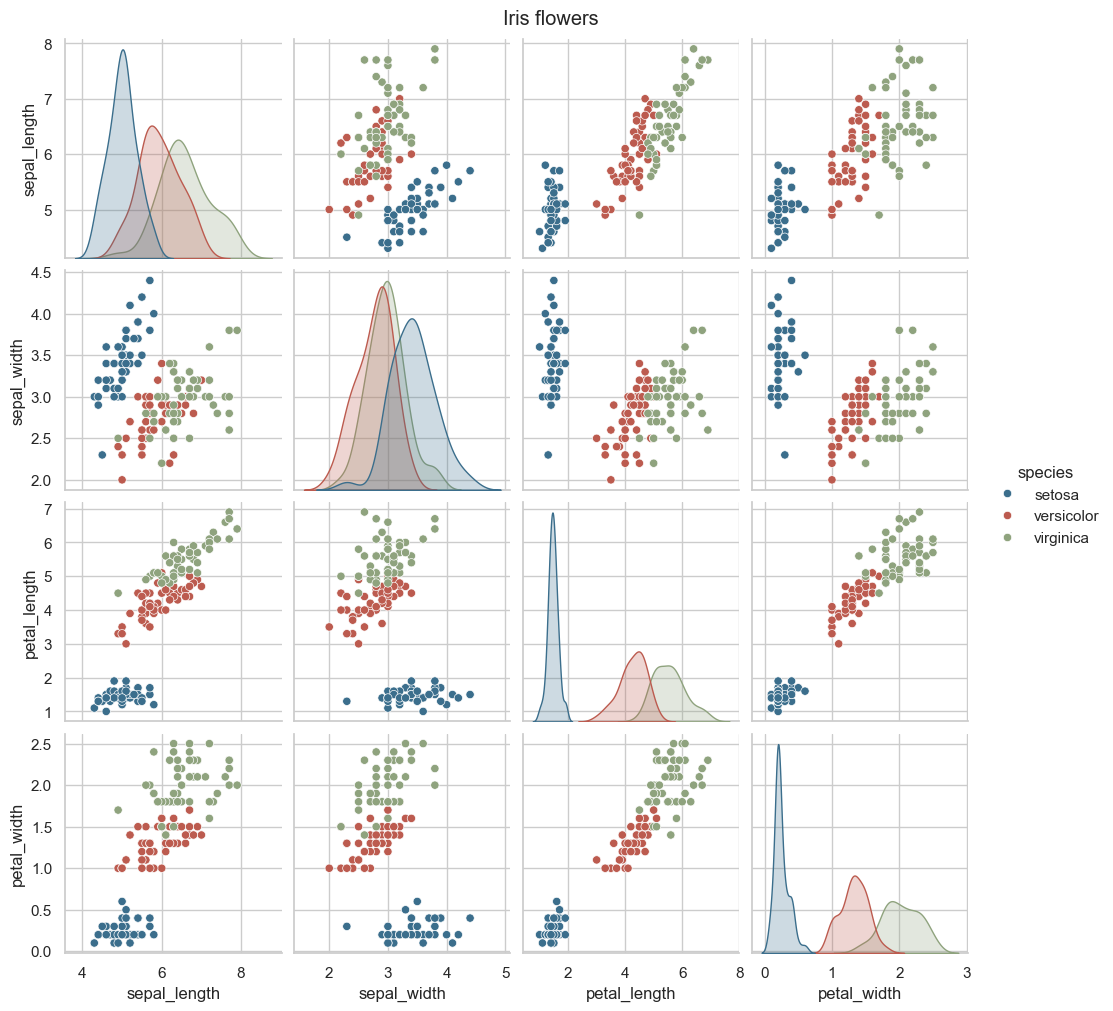

In [5]:
from clustergram import Clustergram
import urbangrammar_graphics as ugg
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale

sns.set(style='whitegrid')
iris = sns.load_dataset("iris")
g = sns.pairplot(iris, hue="species", palette=ugg.COLORS[1:4])
g.fig.suptitle("Iris flowers", y=1.01)

In [6]:
import pandas as pd
import numpy as np

print('Your pandas version is: %s'% pd.__version__)
print('Your NumPy version is %s' % np.__version__)
from sklearn.datasets import load_iris
iris = load_iris()
iris_nparray = iris.data

iris_dataframe = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_dataframe['group'] = pd.Series([iris.target_names[k] for k in iris.target], dtype='category')

Your pandas version is: 2.2.3
Your NumPy version is 1.26.4


In [13]:
print(iris_dataframe.mean(numeric_only=True))

print(iris_dataframe.median(numeric_only=True))


sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64
sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64


In [14]:
print(iris_dataframe.std(numeric_only=True))

sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64


In [15]:
numeric_data = iris_dataframe.select_dtypes(include=['number'])
print(numeric_data.std())

sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64


In [16]:
print (iris_dataframe.max(numeric_only=True)-iris_dataframe.min(numeric_only=True))

sepal length (cm)    3.6
sepal width (cm)     2.4
petal length (cm)    5.9
petal width (cm)     2.4
dtype: float64


In [18]:
print(iris_dataframe.quantile([0, 0.25, 0.50, 0.75, 1], numeric_only=True))

      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0.00                4.3               2.0               1.00               0.1
0.25                5.1               2.8               1.60               0.3
0.50                5.8               3.0               4.35               1.3
0.75                6.4               3.3               5.10               1.8
1.00                7.9               4.4               6.90               2.5


In [19]:
from scipy.stats import skew, skewtest
variable = iris_dataframe['petal length (cm)']
s = skew(variable)
zscore, pvalue = skewtest(variable)
print('Skewness % 0.3f z-score %0.3f p-value %0.3f '% (s, zscore, pvalue))

Skewness -0.272 z-score -1.400 p-value 0.162 


In [20]:
from scipy.stats import kurtosis, kurtosistest
variable = iris_dataframe['petal length (cm)']
k = kurtosis(variable)
zscore, pvalue = kurtosistest(variable)
print ('Kurtosis %0.3f z-score %0.3f p-value %0.3f' % (k, zscore, pvalue))

Kurtosis -1.396 z-score -14.823 p-value 0.000


Завдання 2. Здійсніть обчислення основних категоріальних даних для визначення основних параметричних змінних і якісного цільового результату системного аналізу даних, що характеризують розміри елементів квіток типу іриси.

In [21]:
pcts = [0, .25, .5, .75, 1]
iris_binned = pd.concat(
    [pd.qcut(iris_dataframe.iloc[:,0], pcts, precision=1),
    pd.qcut(iris_dataframe.iloc[:,1], pcts, precision=1),
    pd.qcut(iris_dataframe.iloc[:,2], pcts, precision=1),
    pd.qcut(iris_dataframe.iloc[:,3], pcts, precision=1)],
    join='outer', axis = 1)

In [22]:
print(iris_dataframe['group'].value_counts())

group
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [23]:
print(iris_binned['petal length (cm)'].value_counts())

petal length (cm)
(0.9, 1.6]    44
(4.4, 5.1]    41
(5.1, 6.9]    34
(1.6, 4.4]    31
Name: count, dtype: int64


In [24]:
print(iris_binned.describe())

       sepal length (cm) sepal width (cm) petal length (cm) petal width (cm)
count                150              150               150              150
unique                 4                4                 4                4
top           (4.2, 5.1]       (1.9, 2.8]        (0.9, 1.6]       (0.0, 0.3]
freq                  41               47                44               41


In [25]:
print(pd.crosstab(iris_dataframe['group'], iris_binned['petal length (cm)']))

petal length (cm)  (0.9, 1.6]  (1.6, 4.4]  (4.4, 5.1]  (5.1, 6.9]
group                                                            
setosa                     44           6           0           0
versicolor                  0          25          25           0
virginica                   0           0          16          34


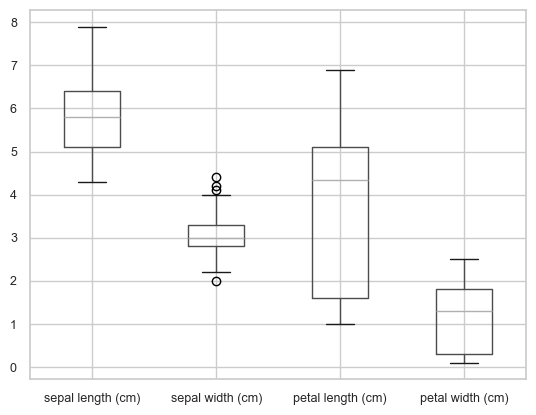

In [26]:
boxplots = iris_dataframe.boxplot(fontsize=9)

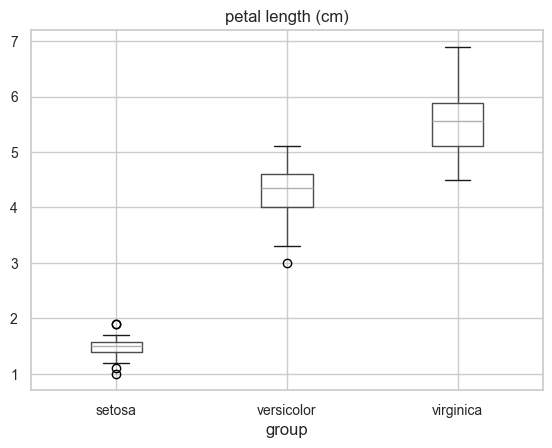

In [27]:
import matplotlib.pyplot as pit
boxplots = iris_dataframe.boxplot(column='petal length (cm)', by='group', fontsize=10)
pit.suptitle('')
pit.show()

In [29]:
from scipy.stats import ttest_ind

group0 = iris_dataframe['group'] == 'setosa'
group1 = iris_dataframe['group'] == 'versicolor'
group2 = iris_dataframe['group'] == 'virginica'
variable = iris_dataframe['petal length (cm)']

print('varl %0.3f var2 %03f' %(variable[group1].var(),variable[group2].var()))

varl 0.221 var2 0.304588


In [30]:
variable = iris_dataframe['sepal width (cm)']
t, pvalue = ttest_ind(variable[group1], variable[group2], axis=0, equal_var=False)
print('t statistic %0.3f p-value %0.3f' % (t, pvalue))

t statistic -3.206 p-value 0.002


In [31]:
from scipy.stats import f_oneway
variable = iris_dataframe['sepal width (cm)']
f, pvalue = f_oneway(variable[group0],
 variable[group1],
 variable[group2])
print('One-way ANOVA F-value %0.3f p-value %0.3f'% (f,pvalue))

One-way ANOVA F-value 49.160 p-value 0.000


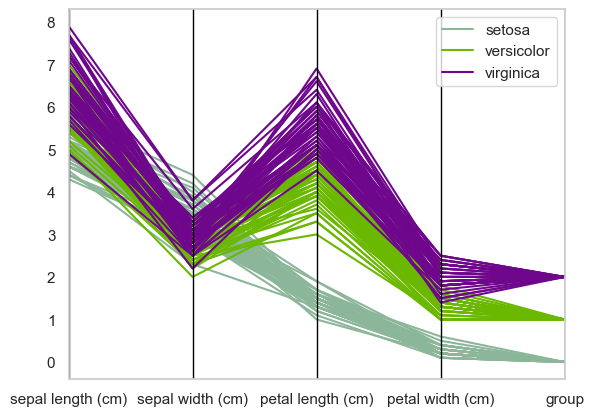

In [32]:
iris = load_iris()
iris_dataframe = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_dataframe['group'] = pd.Series([iris.target_names[k] for k in iris.target], dtype='category')
from pandas.plotting import parallel_coordinates
iris_dataframe['group'] = iris.target
iris_dataframe['labels'] = [iris.target_names[k] for k in iris_dataframe['group']]
pll = parallel_coordinates(iris_dataframe, 'labels')

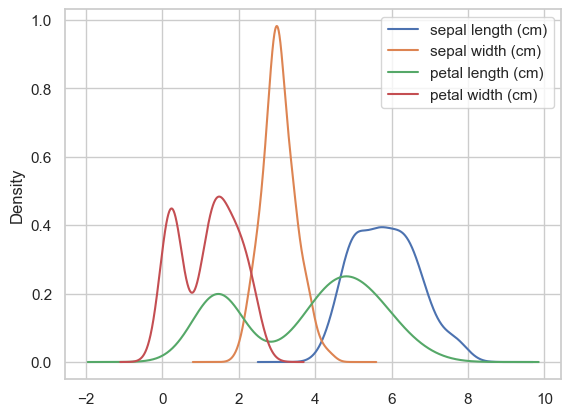

In [ ]:
#Повний розподіл значень представляється на діаграмі розмаху або у вигляді кривої чи гістограми
cols=iris_dataframe.columns[:4]
densityplot = iris_dataframe[cols].plot(kind='density')

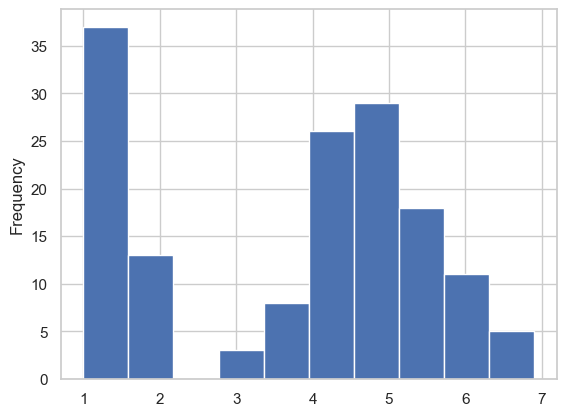

In [ ]:
#Гістограми представляють собою більш детальний вид функції розподілу
variable = iris_dataframe['petal length (cm)']
single_distribution = variable.plot(kind= 'hist')

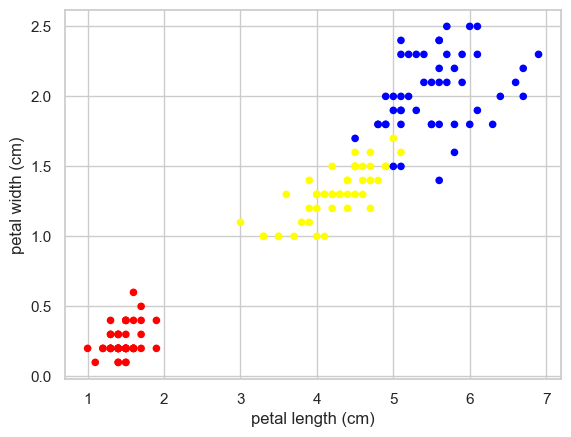

In [ ]:
palette = {0:'red', 1:'yellow', 2:'blue'}
colors = [palette[c] for c in iris_dataframe['group']]
simple_scatterplot = iris_dataframe.plot(kind='scatter', x='petal length (cm)', y='petal width (cm)', c=colors)

#Якщо сукупність точок (хмара) має витягнуту форму (нагадує лінію), можна дійти невтішного висновку про корельованість даних

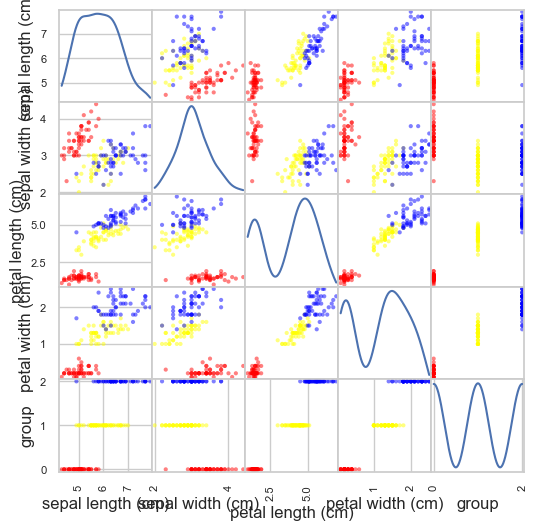

In [37]:
from pandas.plotting import scatter_matrix
palette = {0:'red', 1:'yellow', 2:'blue'}
colors = [palette[c] for c in iris_dataframe['group']]
matrix_of_scatterplots = scatter_matrix(iris_dataframe, figsize=(6, 6), color=colors, diagonal='kde')

In [43]:
numeric_data = iris_dataframe.select_dtypes(include=['number'])
print(numeric_data.cov())

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           0.685694         -0.042434           1.274315   
sepal width (cm)           -0.042434          0.189979          -0.329656   
petal length (cm)           1.274315         -0.329656           3.116278   
petal width (cm)            0.516271         -0.121639           1.295609   
group                       0.530872         -0.152349           1.372483   

                   petal width (cm)     group  
sepal length (cm)          0.516271  0.530872  
sepal width (cm)          -0.121639 -0.152349  
petal length (cm)          1.295609  1.372483  
petal width (cm)           0.581006  0.597315  
group                      0.597315  0.671141  


In [47]:
numeric_data = iris_dataframe.select_dtypes(include=['number'])
print(numeric_data.corr())

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
group                       0.782561         -0.426658           0.949035   

                   petal width (cm)     group  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
group                      0.956547  1.000000  


In [49]:
from scipy.stats import spearmanr
from scipy.stats.stats import pearsonr
a = iris_dataframe['sepal length (cm)']
b = iris_dataframe['sepal width (cm)']
rho_coef, rho_p = spearmanr(a, b)
r_coef, r_p = pearsonr(a, b)
print('Pearson r %0.3f I Spearman rho %0.3f' % (r_coef, rho_coef))

Pearson r -0.118 I Spearman rho -0.167


C:\Users\porsh\AppData\Local\Temp\ipykernel_11152\2606980028.py:2: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


In [50]:
from scipy.stats import chi2_contingency
table = pd.crosstab(iris_dataframe['group'], iris_binned['petal length (cm)'])
chi2, p, dof, expected = chi2_contingency(table.values)
print('Chi-square %0.2f p-value %0.3f' % (chi2, p))

Chi-square 212.43 p-value 0.000


Завдання 3. На основі методів розвідувального аналізу даних EDA реалізуйте візуалізацію основних статистичних характеристик квіткового набору даних.

In [51]:
from sklearn.preprocessing import scale
variable = iris_dataframe['sepal width (cm)']
stand_sepal_width = scale(variable)

In [53]:
from scipy.stats.stats import pearsonr
tranformations = {'x': lambda x: x,'1/x':
        lambda x: 1/x,'x**2':
        lambda x: x**2,'x**3':
        lambda x: x**3,
        'log(x)': lambda x: np.log(x)}
a = iris_dataframe['sepal length (cm)']
b = iris_dataframe['sepal width (cm)']
for transformation in tranformations:
    b_transformed = tranformations[transformation](b)
    pearsonr_coef, pearsonr_p = pearsonr(a, b_transformed)
    print('Transformation: %s \t Pearson\'s r: %0.3f'% (transformation, pearsonr_coef))

Transformation: x 	 Pearson's r: -0.118
Transformation: 1/x 	 Pearson's r: 0.080
Transformation: x**2 	 Pearson's r: -0.131
Transformation: x**3 	 Pearson's r: -0.140
Transformation: log(x) 	 Pearson's r: -0.100


C:\Users\porsh\AppData\Local\Temp\ipykernel_11152\1983111093.py:1: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


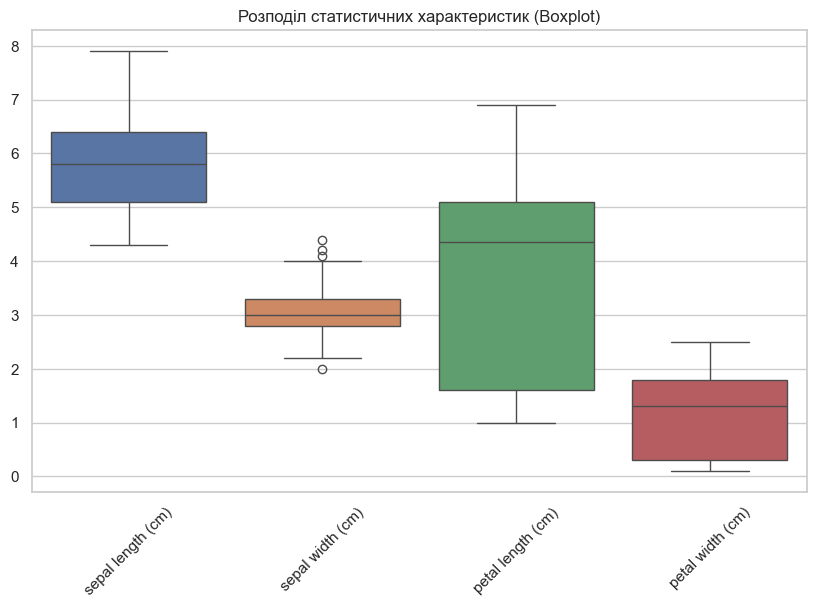

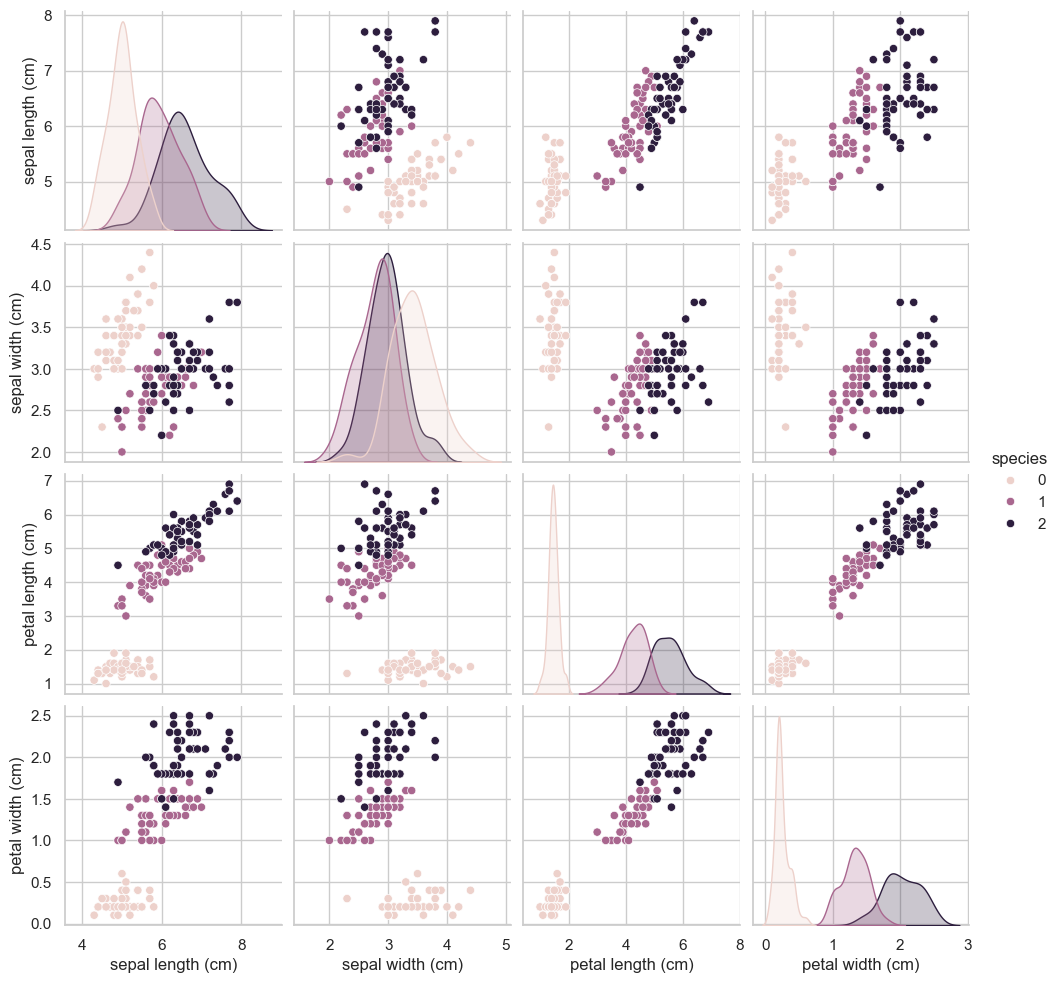

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets

# Завантажуємо вбудований датасет Iris
dataset = datasets.load_iris()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target

# Завдання 3: Візуалізація основних статистичних характеристик (EDA)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.iloc[:, :-1])
plt.title("Розподіл статистичних характеристик (Boxplot)")
plt.xticks(rotation=45)
plt.show()

sns.pairplot(df, hue="species", diag_kind="kde")
plt.show()


Завдання 4. Проаналізуйте параметри кореляції та коваріації для набору даних, що характеризують розміри елементів квіток типу іриси, а також здійсніть новий розподіл даних.

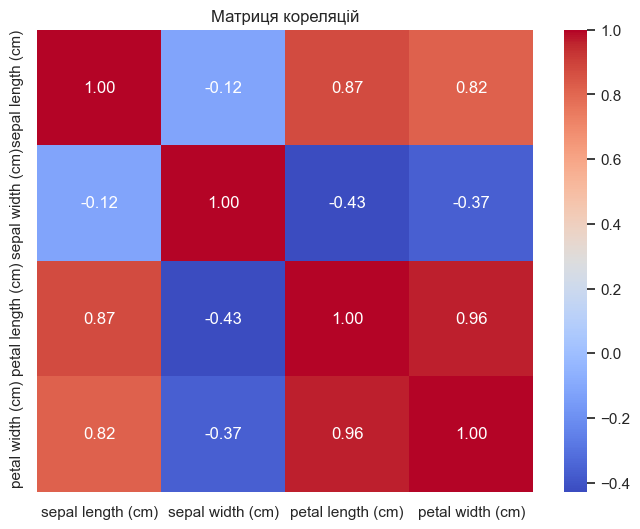

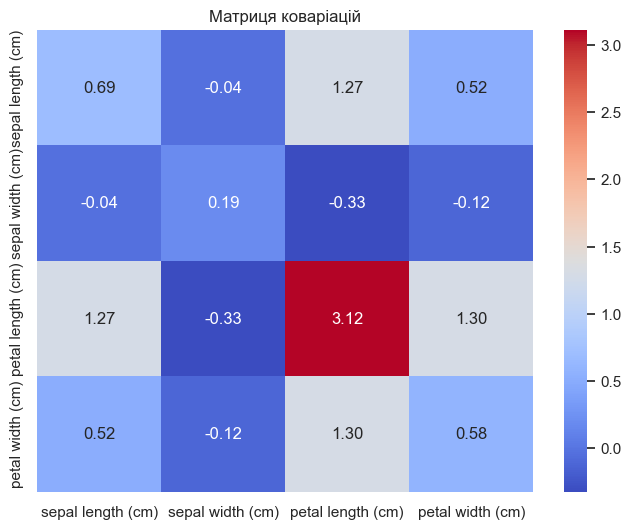

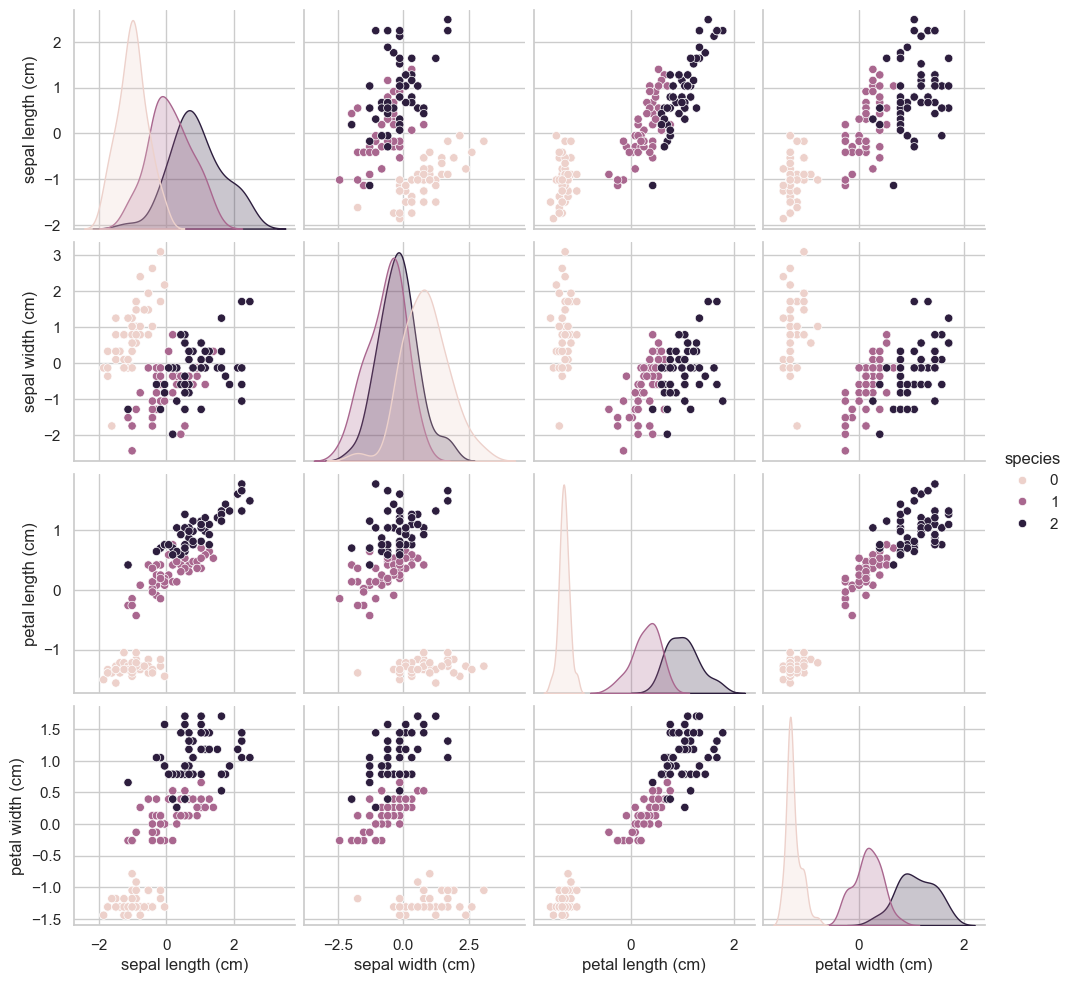

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets

# Завантажуємо вбудований датасет Iris
dataset = datasets.load_iris()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target

# Завдання 4: Аналіз кореляції та коваріації + новий розподіл даних
correlation_matrix = df.iloc[:, :-1].corr()
covariance_matrix = df.iloc[:, :-1].cov()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матриця кореляцій")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(covariance_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матриця коваріацій")
plt.show()

# Новий розподіл даних (нормалізація)
df_normalized = (df.iloc[:, :-1] - df.iloc[:, :-1].mean()) / df.iloc[:, :-1].std()
df_normalized['species'] = df['species']

sns.pairplot(df_normalized, hue="species", diag_kind="kde")
plt.show()
